Descargando el Dataset Climático de Jena (2009-2016)... Esto puede tardar unos segundos.
Comprimiendo lecturas de 10 minutos a medias diarias...
Dataset listo: 2921 días detectados con 14 dimensiones físicas.
------------------------------------------------------------
Días de Entrenamiento (Pasado): 2336
Días de Prueba (Futuro):        585
------------------------------------------------------------
Entrenando Diccionario de 30 átomos con los 2336 días del pasado...
Congelando diccionario y codificando los días del futuro...

 RESULTADOS EXACTOS DE GENERALIZACIÓN (JENA CLIMATE)
 MSE Exacto en Entrenamiento: 0.1099
 MSE Exacto en Prueba (Test): 0.2725
 Esparcidad en Prueba:        89.74% de ceros estrictos


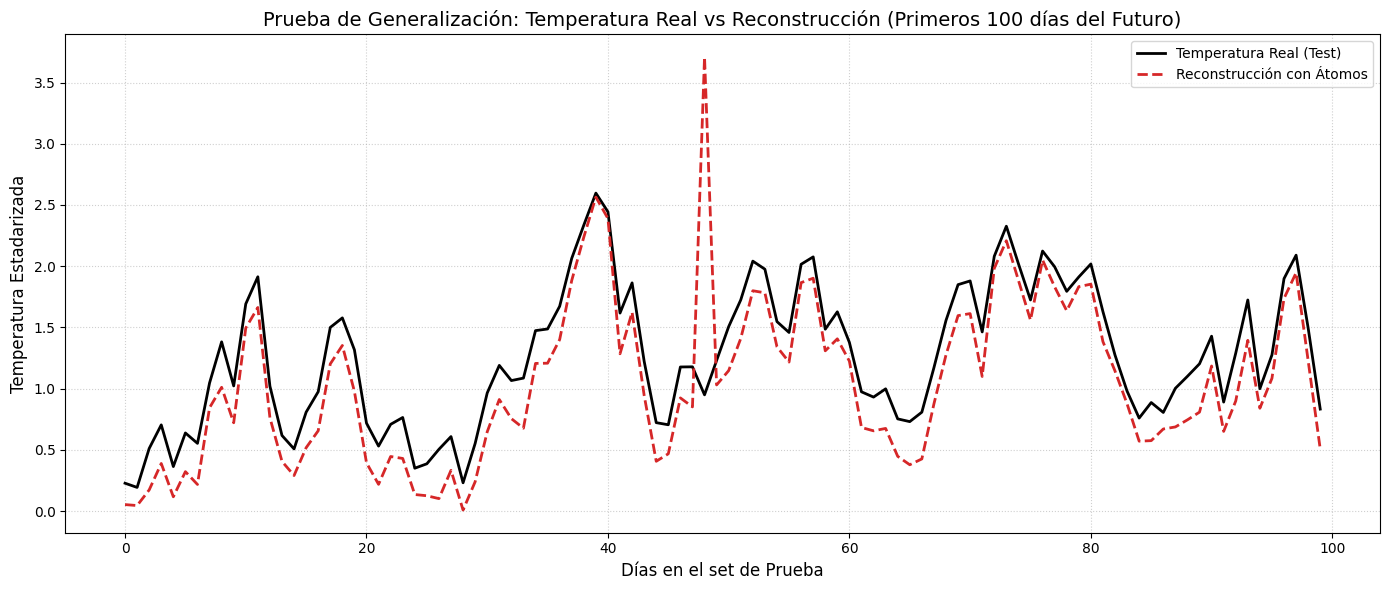

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) IMPORTACIÓN Y PROCESAMIENTO DEL DATASET DE JENA (7 AÑOS)
# ==========================================
print("Descargando el Dataset Climático de Jena (2009-2016)... Esto puede tardar unos segundos.")
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
data = pd.read_csv(url)

# Convertimos la fecha a formato matemático y la ponemos como índice
data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')
data.set_index('Date Time', inplace=True)

# El dataset original tiene datos cada 10 minutos (más de 420.000 filas).
# Lo agrupamos por DÍA ('D') calculando la media física exacta de cada jornada.
print("Comprimiendo lecturas de 10 minutos a medias diarias...")
df_diario = data.resample('D').mean().dropna()

X_raw = df_diario.select_dtypes(include=[np.number])
dimension_real = X_raw.shape[1]
dias_totales = X_raw.shape[0]

print(f"Dataset listo: {dias_totales} días detectados con {dimension_real} dimensiones físicas.")
print("-" * 60)

# ==========================================
# 2) DIVISIÓN CRONOLÓGICA (TRAIN/TEST)
# ==========================================
# NO usamos shuffle. Entrenamos con el pasado para evaluar en el futuro.
corte = int(dias_totales * 0.80) # 80% para entrenar (aprox 5.5 años), 20% para test (aprox 1.5 años)

X_train_raw = X_raw.iloc[:corte]
X_test_raw = X_raw.iloc[corte:]

# Escalamos basándonos SOLO en el Train (regla estricta de Machine Learning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Días de Entrenamiento (Pasado): {X_train_scaled.shape[0]}")
print(f"Días de Prueba (Futuro):        {X_test_scaled.shape[0]}")
print("-" * 60)

# ==========================================
# 3) APRENDIZAJE DEL DICCIONARIO
# ==========================================
# Como tenemos 14 variables, un diccionario de 30 átomos ya es muy sobrecompleto
n_atoms = 30 
print(f"Entrenando Diccionario de {n_atoms} átomos con los {X_train_scaled.shape[0]} días del pasado...")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

# El algoritmo aprende los átomos usando solo el Train
sparse_train = dict_learner.fit_transform(X_train_scaled)
dictionary_atoms = dict_learner.components_

# Calculamos el MSE Exacto de entrenamiento
X_train_reconstructed = np.dot(sparse_train, dictionary_atoms)
mse_train_exacto = mean_squared_error(X_train_scaled, X_train_reconstructed)

# ==========================================
# 4) GENERALIZACIÓN Y PRUEBA EN EL FUTURO
# ==========================================
print("Congelando diccionario y codificando los días del futuro...")

# Usamos transform() para obligar al algoritmo a usar los átomos que ya conoce
sparse_test = dict_learner.transform(X_test_scaled)

# Calculamos el MSE Exacto en la prueba
X_test_reconstructed = np.dot(sparse_test, dictionary_atoms)
mse_test_exacto = mean_squared_error(X_test_scaled, X_test_reconstructed)

# Porcentaje de esparcidad (ceros absolutos) en los datos del futuro
ceros_exactos = np.sum(np.abs(sparse_test) < 1e-5)
sparsity_pct_test = (ceros_exactos / sparse_test.size) * 100

print("\n" + "="*60)
print(" RESULTADOS EXACTOS DE GENERALIZACIÓN (JENA CLIMATE)")
print("="*60)
print(f" MSE Exacto en Entrenamiento: {mse_train_exacto:.4f}")
print(f" MSE Exacto en Prueba (Test): {mse_test_exacto:.4f}")
print(f" Esparcidad en Prueba:        {sparsity_pct_test:.2f}% de ceros estrictos")
print("="*60)

# ==========================================
# 5) GRÁFICA COMPARATIVA DE RECONSTRUCCIÓN (OPCIONAL PERO POTENTE)
# ==========================================
# Vamos a aislar 1 sola variable física del futuro (ej. Temperatura en Celsius) 
# para que el profesor vea visualmente cómo el modelo clava la reconstrucción.

indice_temp = X_raw.columns.get_loc('T (degC)')
dias_a_graficar = 100 # Primeros 100 días del Test

plt.figure(figsize=(14, 6))
plt.plot(X_test_scaled[:dias_a_graficar, indice_temp], label='Temperatura Real (Test)', color='black', linewidth=2)
plt.plot(X_test_reconstructed[:dias_a_graficar, indice_temp], label='Reconstrucción con Átomos', color='tab:red', linestyle='dashed', linewidth=2)

plt.title('Prueba de Generalización: Temperatura Real vs Reconstrucción (Primeros 100 días del Futuro)', fontsize=14)
plt.ylabel('Temperatura Estadarizada', fontsize=12)
plt.xlabel('Días en el set de Prueba', fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Descargando y preparando el Dataset de Jena...
Entrenando el vocabulario base de 30 átomos...
Generando radiografía de los átomos en pantalla...


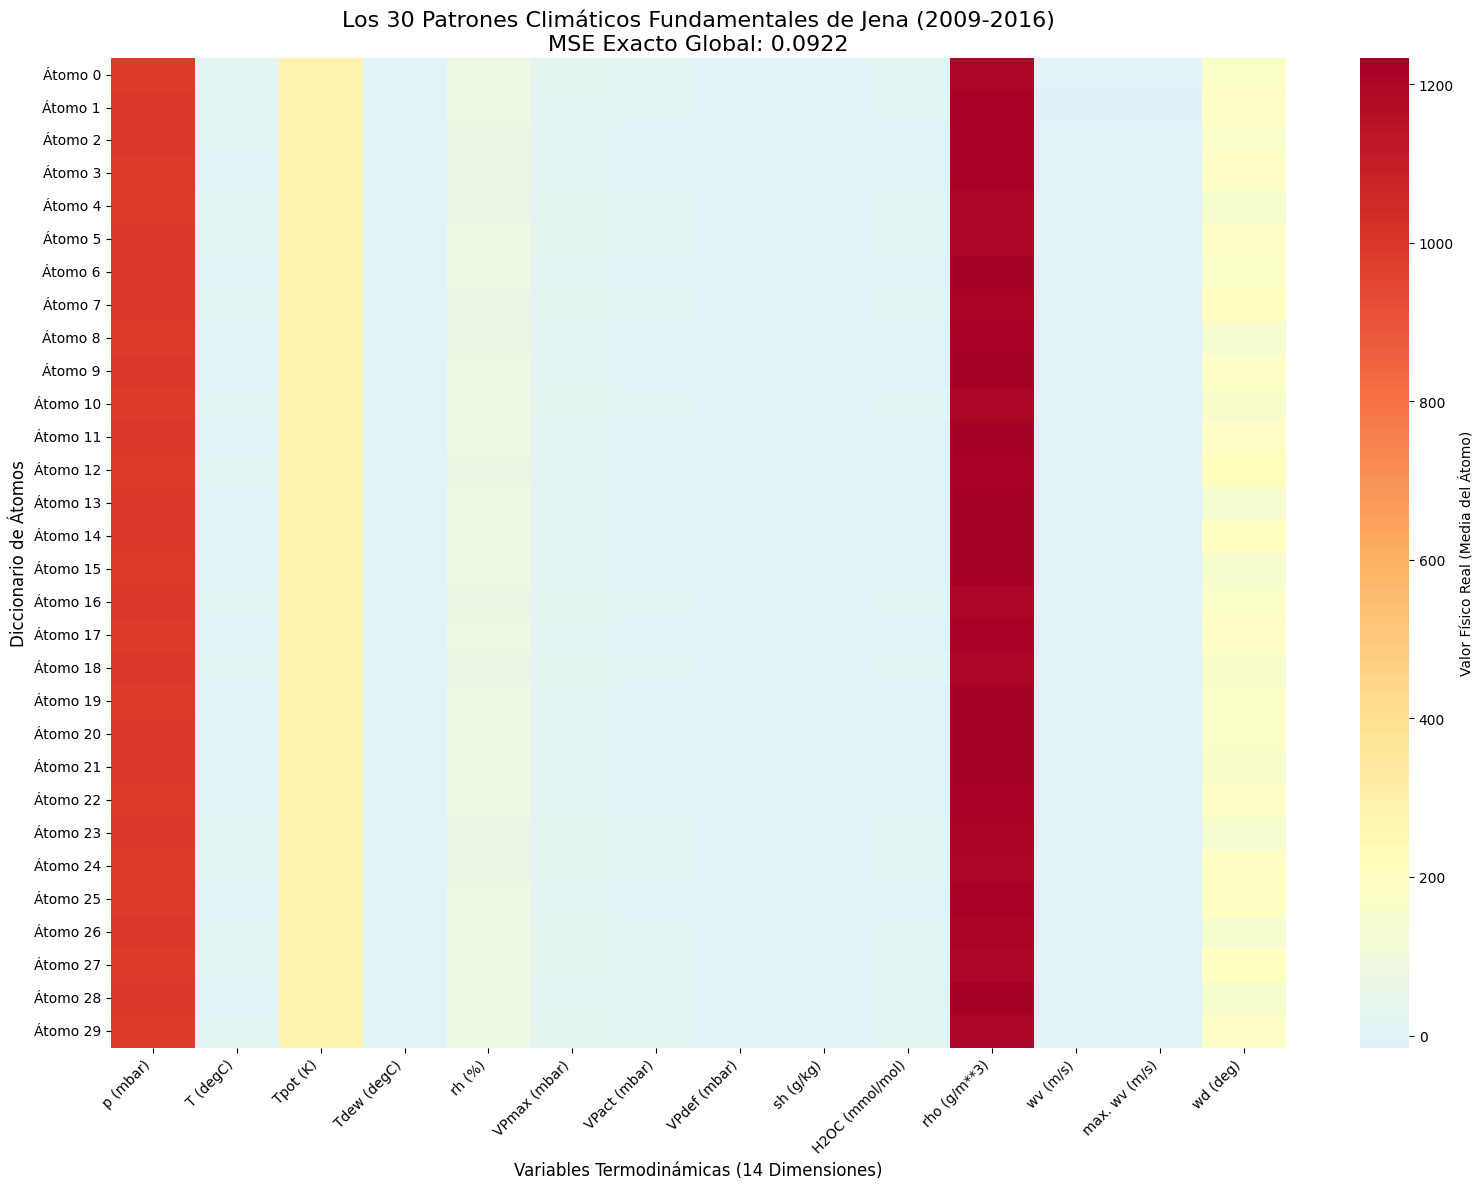

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) IMPORTACIÓN Y PROCESAMIENTO (JENA CLIMATE)
# ==========================================
print("Descargando y preparando el Dataset de Jena...")
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
data = pd.read_csv(url)

data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')
data.set_index('Date Time', inplace=True)

# Comprimimos a medias diarias
df_diario = data.resample('D').mean().dropna()
X_raw = df_diario.select_dtypes(include=[np.number])
nombres_variables = X_raw.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ==========================================
# 2) ENTRENAMIENTO DEL DICCIONARIO
# ==========================================
n_atoms = 30 
print(f"Entrenando el vocabulario base de {n_atoms} átomos...")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=1.0, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000
)

sparse_representation = dict_learner.fit_transform(X_scaled)
dictionary_atoms = dict_learner.components_

# Cálculo exacto del error matemático
X_reconstructed = np.dot(sparse_representation, dictionary_atoms)
mse_exacto = mean_squared_error(X_scaled, X_reconstructed)

# ==========================================
# 3) TRADUCCIÓN A VALORES FÍSICOS REALES
# ==========================================
# Deshacemos el escalado para ver temperaturas y presiones reales
interpreted_atoms = scaler.inverse_transform(dictionary_atoms)
df_atoms = pd.DataFrame(interpreted_atoms, columns=nombres_variables)
df_atoms.index = [f"Átomo {i}" for i in range(n_atoms)]

# ==========================================
# 4) VISUALIZACIÓN EN PANTALLA: MAPA DE CALOR
# ==========================================
print("Generando radiografía de los átomos en pantalla...")

plt.figure(figsize=(16, 12))
# Usamos un mapa de color divergente (azul para valores bajos, rojo para altos)
sns.heatmap(df_atoms, cmap="RdYlBu_r", center=df_atoms.mean().mean(), 
            cbar_kws={'label': 'Valor Físico Real (Media del Átomo)'})

plt.title(f"Los 30 Patrones Climáticos Fundamentales de Jena (2009-2016)\nMSE Exacto Global: {mse_exacto:.4f}", fontsize=16)
plt.ylabel("Diccionario de Átomos", fontsize=12)
plt.xlabel("Variables Termodinámicas (14 Dimensiones)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Descargando dataset de Jena...
Entrenando Diccionario de 30 átomos con el pasado...
Reconstruyendo todos los días del futuro (Test)...

[!] MSE Exacto General en el Test: 0.2725
-> La variable PEOR reconstruida es 'wv (m/s)' con un MSE de 1.0886
-> La variable MEJOR reconstruida es 'Tpot (K)' con un MSE de 0.0648
------------------------------------------------------------
Generando el panel de las 14 gráficas...


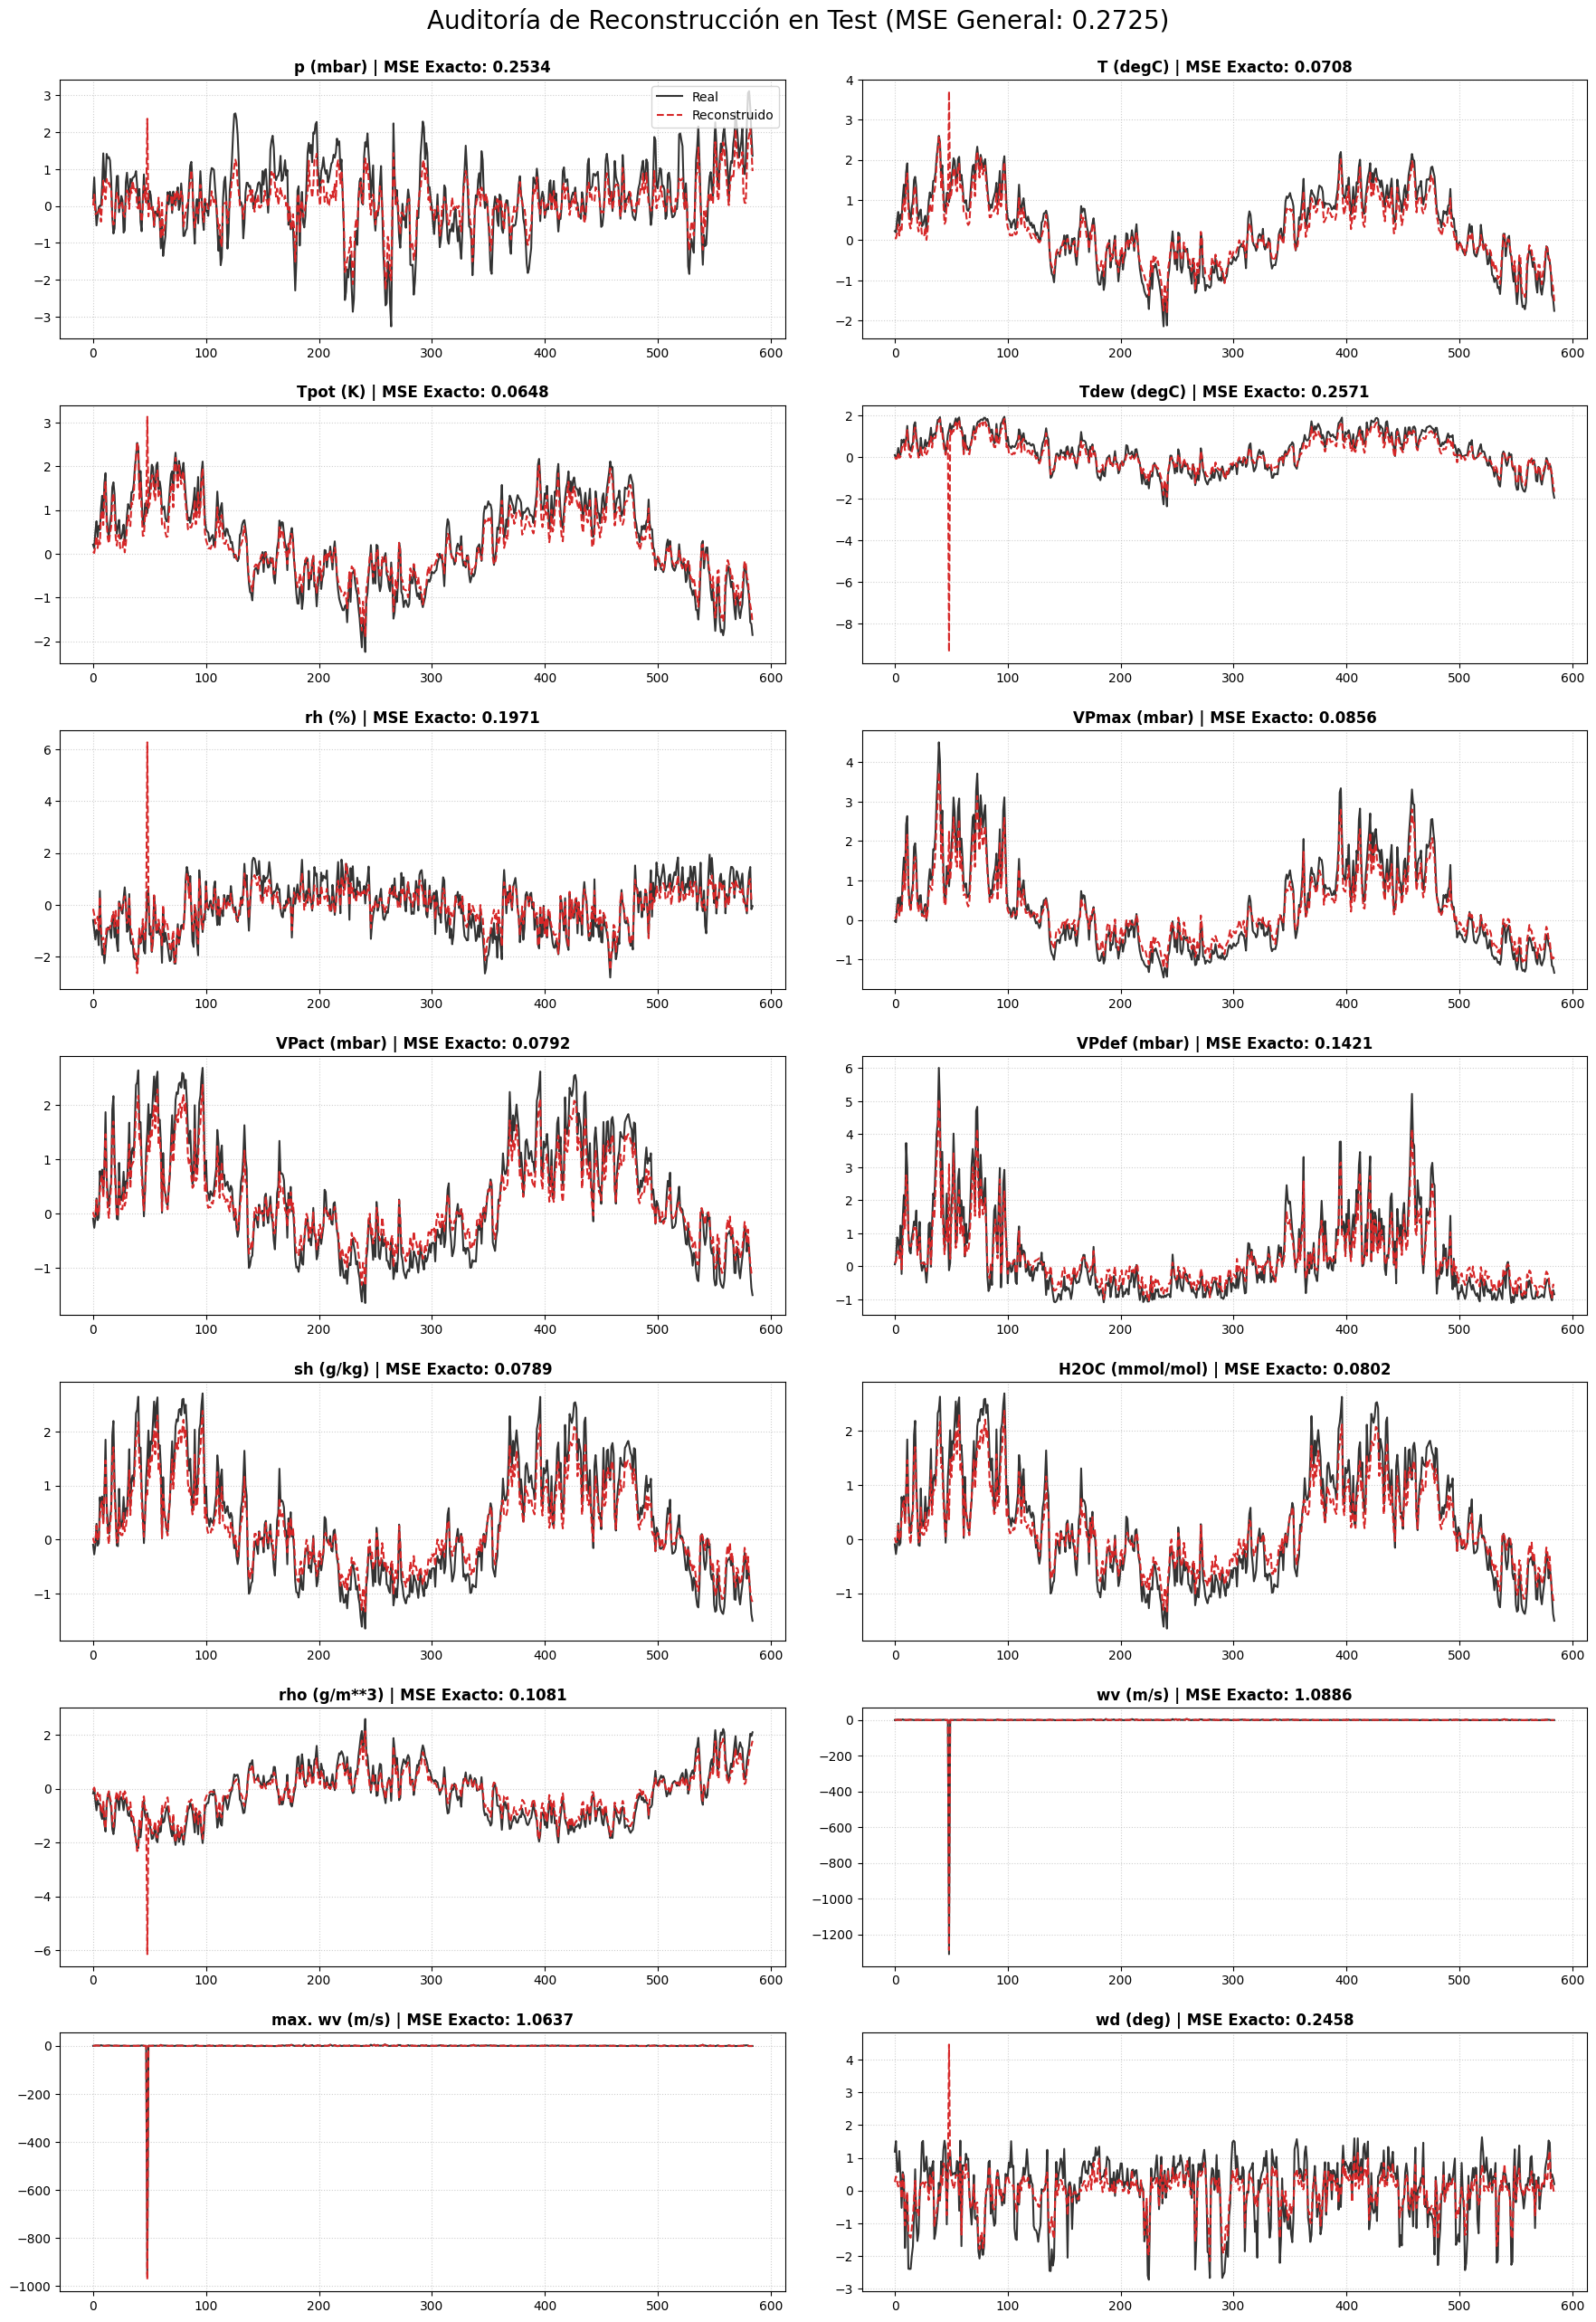

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ==========================================
# 1) IMPORTACIÓN Y PREPARACIÓN DEL DATASET (JENA)
# ==========================================
print("Descargando dataset de Jena...")
url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
data = pd.read_csv(url)

data['Date Time'] = pd.to_datetime(data['Date Time'], format='%d.%m.%Y %H:%M:%S')
data.set_index('Date Time', inplace=True)

# Comprimimos a medias diarias exactas
df_diario = data.resample('D').mean().dropna()
X_raw = df_diario.select_dtypes(include=[np.number])
nombres_variables = X_raw.columns.tolist()

dimension_real = X_raw.shape[1]
dias_totales = X_raw.shape[0]

# ==========================================
# 2) DIVISIÓN CRONOLÓGICA (TRAIN/TEST)
# ==========================================
corte = int(dias_totales * 0.80)
X_train_raw = X_raw.iloc[:corte]
X_test_raw = X_raw.iloc[corte:]  # TODOS los días del test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ==========================================
# 3) ENTRENAMIENTO Y RECONSTRUCCIÓN DEL FUTURO
# ==========================================
n_atoms = 30 
print("Entrenando Diccionario de 30 átomos con el pasado...")
dict_learner = DictionaryLearning(n_components=n_atoms, alpha=1.0, transform_algorithm='lasso_lars', random_state=42, max_iter=1000)

dict_learner.fit(X_train_scaled) # Aprende del pasado
dictionary_atoms = dict_learner.components_

print("Reconstruyendo todos los días del futuro (Test)...")
sparse_test = dict_learner.transform(X_test_scaled) # Usa los átomos en el futuro
X_test_reconstructed = np.dot(sparse_test, dictionary_atoms)

# ==========================================
# 4) CÁLCULO DE ERRORES EXACTOS
# ==========================================
# MSE Global estricto
mse_global_test = mean_squared_error(X_test_scaled, X_test_reconstructed)
print(f"\n[!] MSE Exacto General en el Test: {mse_global_test:.4f}")

# MSE por cada variable
errores_por_variable = {}
for i, nombre in enumerate(nombres_variables):
    mse_var = mean_squared_error(X_test_scaled[:, i], X_test_reconstructed[:, i])
    errores_por_variable[nombre] = mse_var

# Identificamos la mejor y la peor variable
peor_var = max(errores_por_variable, key=errores_por_variable.get)
mejor_var = min(errores_por_variable, key=errores_por_variable.get)

print(f"-> La variable PEOR reconstruida es '{peor_var}' con un MSE de {errores_por_variable[peor_var]:.4f}")
print(f"-> La variable MEJOR reconstruida es '{mejor_var}' con un MSE de {errores_por_variable[mejor_var]:.4f}")
print("-" * 60)

# ==========================================
# 5) PANEL DE 14 GRÁFICAS COMPARATIVAS
# ==========================================
print("Generando el panel de las 14 gráficas...")

# Creamos una cuadrícula grande de 7 filas y 2 columnas
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(18, 26))
fig.suptitle(f'Auditoría de Reconstrucción en Test (MSE General: {mse_global_test:.4f})', fontsize=20, y=0.99)

axes = axes.flatten() # Aplanamos para iterar fácilmente

for i, nombre_var in enumerate(nombres_variables):
    ax = axes[i]
    mse_local = errores_por_variable[nombre_var]
    
    # Dibujamos Realidad vs Reconstrucción
    ax.plot(X_test_scaled[:, i], color='black', label='Real', linewidth=1.5, alpha=0.8)
    ax.plot(X_test_reconstructed[:, i], color='tab:red', label='Reconstruido', linewidth=1.5, linestyle='--')
    
    ax.set_title(f"{nombre_var} | MSE Exacto: {mse_local:.4f}", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Solo ponemos leyenda en la primera para no saturar
    if i == 0:
        ax.legend(loc="upper right")

# Ajustamos espacios para que quede elegante
plt.tight_layout(pad=2.0)
fig.subplots_adjust(top=0.96)
plt.show()